# Tutorial

# Step 1: Check the `Google_Colab_Instruction.pdf`

If you are using Google Colab; skip if locally

# Step 2: Clone the repo 

In [ ]:
!git clone https://github.com/runyao-yu/PriceFM.git
%cd PriceFM
!pip install -r requirements.txt

Cloning into 'PriceFM'...
remote: Enumerating objects: 275, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 275 (delta 16), reused 42 (delta 9), pack-reused 225 (from 2)
Receiving objects: 100% (275/275), 131.73 MiB | 19.73 MiB/s, done.
Resolving deltas: 100% (43/43), done.
/content/PriceFM


# Step 3: Define experimental settings

In [ ]:

from PriceFM import *
import pandas as pd
import numpy as np

# 3 folds
train_val_test_splits = [("2022-01-01", "2024-09-01", "2024-09-01", "2025-01-01", "2025-01-01", "2025-05-01"),
                         ("2022-01-01", "2025-01-01", "2025-01-01", "2025-05-01", "2025-05-01", "2025-09-01"),
                         ("2022-01-01", "2025-05-01", "2025-05-01", "2025-09-01", "2025-09-01", "2026-01-01")]

train_start, train_end, val_start, val_end, test_start, test_end = train_val_test_splits[2]

countries = [
    "AT", "BE", "BG", "CZ", "DE_LU", "DK_1", "DK_2",
    "EE", "ES", "FI", "FR", "GR",    "HR", "HU",
    "IT_CALA", "IT_CNOR", "IT_CSUD", "IT_NORD", "IT_SARD", "IT_SICI", "IT_SUD",
    "LT", "LV", "NL", "NO_1", "NO_2", "NO_3", "NO_4", "NO_5",
    "PL", "PT", "RO", "SE_1", "SE_2", "SE_3", "SE_4", "SI", "SK",
]

label_column = "price"
lag_features  = ["price", "load",  "solar", "wind"]
lead_features = ["load",  "solar", "wind"]
features = sorted((set(lag_features) | set(lead_features)) - {label_column})

lag_window      = 96
lead_window     = 96

rolling_train = {}
rolling_val   = {}
rolling_test  = {}

adjacency_dict = graph_adj_matrix()

# # Step 4: Data processing

- read data
- split into train, val, test
- scale
- separate by country code
- rolling window to create samples

In [4]:
#!pip install -q huggingface_hub

from huggingface_hub import hf_hub_download

# read df
file_path = hf_hub_download(
    repo_id="RunyaoYu/PriceFM",
    filename="FINAL.csv",
    repo_type="dataset"
)

df = read_dataset(file_path)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


FINAL.csv:   0%|          | 0.00/195M [00:00<?, ?B/s]

In [5]:
# split into train val test
df_train, df_val, df_test = split_dataframe(df, train_start, train_end, val_start, val_end, test_start, test_end)

# scale df
#df_train_s, df_val_s, df_test_s, x_scaler, y_scaler = scale_dataframe_eu_level(df_train, df_val, df_test)
df_train_s, df_val_s, df_test_s, x_scalers, y_scalers = scale_dataframe_per_country(df_train, df_val, df_test, countries, features, label_column)

# separate each country
train_sep = separate_countries(df_train_s, countries, features, label_column)
val_sep   = separate_countries(df_val_s,   countries, features, label_column)
test_sep  = separate_countries(df_test_s,  countries, features, label_column)

# rolling window
for c in countries:
    X_lag_tr, X_lead_tr, Y_tr, t_tr = make_rolling_window_samples(
        train_sep[c], c, lag_features, lead_features, label_column, lag_window, lead_window
    )
    X_lag_va, X_lead_va, Y_va, t_va = make_rolling_window_samples(
        val_sep[c],   c, lag_features, lead_features, label_column, lag_window, lead_window
    )
    X_lag_te, X_lead_te, Y_te, t_te = make_rolling_window_samples(
        test_sep[c],  c, lag_features, lead_features, label_column, lag_window, lead_window
    )

    rolling_train[c] = {"X_lag": X_lag_tr, "X_lead": X_lead_tr, "Y": Y_tr, "t": t_tr}
    rolling_val[c]   = {"X_lag": X_lag_va, "X_lead": X_lead_va, "Y": Y_va, "t": t_va}
    rolling_test[c]  = {"X_lag": X_lag_te, "X_lead": X_lead_te, "Y": Y_te, "t": t_te}

# add graph adjacency to rolling_train/val/test
df_train, df_val, df_test = add_adj_dict_to_rollings(
    adjacency_dict,
    rolling_train,
    rolling_val,
    rolling_test,
    countries,
)

# Modeling & Evaluation

## 1. Pretraining

Requirement: input_countries_pretrain == output_countries_pretrain == output_countries_test <- 'all countries'

In [ ]:
quantiles =  [0.10, 0.25, 0.45, 0.50, 0.55, 0.75, 0.90]
emb_dim, num_experts, epochs, batch_size = 24*len(quantiles), 4, 50, 128

input_countries_pretrain = countries
output_countries_pretrain = countries
output_countries_test = countries

In [ ]:
test_metrics = pipline_phase_I(input_countries_pretrain, output_countries_pretrain, output_countries_test,
                                df_train, df_val, df_test, y_scalers,
                                emb_dim, num_experts, epochs, batch_size, quantiles)

rows = []
for c in output_countries_test:
    rows.append({
        "target_country": c,
        **test_metrics[c]
    })

df_results = pd.DataFrame(rows)
df_results.to_csv("Result/phase1_pretraining.csv", index=False)
print("\nSaved:", "Result/phase1_pretraining.csv")

# average metrics
avg_test_metrics = {
    k: float(np.mean([test_metrics[c][k] for c in output_countries_test]))
    for k in next(iter(test_metrics.values())).keys()
}
print("Average metrics:", avg_test_metrics)


=== Phase I: Pretraining ===
Input  Countries for Pretraining: ['AT', 'BE', 'BG', 'CZ', 'DE_LU', 'DK_1', 'DK_2', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'HU', 'IT_CALA', 'IT_CNOR', 'IT_CSUD', 'IT_NORD', 'IT_SARD', 'IT_SICI', 'IT_SUD', 'LT', 'LV', 'NL', 'NO_1', 'NO_2', 'NO_3', 'NO_4', 'NO_5', 'PL', 'PT', 'RO', 'SE_1', 'SE_2', 'SE_3', 'SE_4', 'SI', 'SK']
Output Countries for Pretraining: ['AT', 'BE', 'BG', 'CZ', 'DE_LU', 'DK_1', 'DK_2', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'HU', 'IT_CALA', 'IT_CNOR', 'IT_CSUD', 'IT_NORD', 'IT_SARD', 'IT_SICI', 'IT_SUD', 'LT', 'LV', 'NL', 'NO_1', 'NO_2', 'NO_3', 'NO_4', 'NO_5', 'PL', 'PT', 'RO', 'SE_1', 'SE_2', 'SE_3', 'SE_4', 'SI', 'SK']
Output Countries for Testing: ['AT', 'BE', 'BG', 'CZ', 'DE_LU', 'DK_1', 'DK_2', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'HU', 'IT_CALA', 'IT_CNOR', 'IT_CSUD', 'IT_NORD', 'IT_SARD', 'IT_SICI', 'IT_SUD', 'LT', 'LV', 'NL', 'NO_1', 'NO_2', 'NO_3', 'NO_4', 'NO_5', 'PL', 'PT', 'RO', 'SE_1', 'SE_2', 'SE_3', 'SE_4', 'SI', 'SK']

Epoch 1

## 2. Fine-Tuning

In [ ]:
quantiles =  [0.10, 0.25, 0.45, 0.50, 0.55, 0.75, 0.90]
emb_dim, num_experts, epochs, batch_size = 24*len(quantiles), 4, 20, 128
graph_degrees = [0, 1, 2, 3]

input_countries = countries
target_countries = ['AT']

In [ ]:
for target_country in target_countries:
    rows = []
    for graph_degree in graph_degrees:
        metrics = pipline_phase_II(input_countries, target_country, adjacency_dict, graph_degree,
                                df_train, df_val, df_test, y_scalers,
                                emb_dim, num_experts, epochs, batch_size, quantiles)
        metrics = metrics[target_country]
        row = {
            "target_country": target_country,
            "degree": graph_degree,
            **metrics,
        }
        rows.append(row)

    import pandas as pd
    df_results = pd.DataFrame(rows)
    df_results.to_csv(f"Result/phase2_{target_country}.csv", index=False)
    print("\nSaved:", f"Result/phase2_{target_country}.csv")


=== Phase II: Fine-Tuning ===
Input Countries: ['AT', 'BE', 'BG', 'CZ', 'DE_LU', 'DK_1', 'DK_2', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'HU', 'IT_CALA', 'IT_CNOR', 'IT_CSUD', 'IT_NORD', 'IT_SARD', 'IT_SICI', 'IT_SUD', 'LT', 'LV', 'NL', 'NO_1', 'NO_2', 'NO_3', 'NO_4', 'NO_5', 'PL', 'PT', 'RO', 'SE_1', 'SE_2', 'SE_3', 'SE_4', 'SI', 'SK']
Target country: AT
Graph degree: 0
0.0702219232916832

Epoch 1: val_loss improved from inf to 0.06715, saving model to Model/phase2_best_AT_deg0.keras

Epoch 2: val_loss improved from 0.06715 to 0.06584, saving model to Model/phase2_best_AT_deg0.keras

Epoch 3: val_loss did not improve from 0.06584

Epoch 4: val_loss improved from 0.06584 to 0.06575, saving model to Model/phase2_best_AT_deg0.keras

Epoch 5: val_loss did not improve from 0.06575

Epoch 6: val_loss did not improve from 0.06575

Epoch 7: val_loss did not improve from 0.06575

Epoch 8: val_loss did not improve from 0.06575

Epoch 9: val_loss did not improve from 0.06575

Epoch 10: val_loss did

## 3. Inference using the optimized model

In [25]:
import matplotlib.pyplot as plt
from IPython.display import display
from PriceFM import (
    load_corresponding_date_data,
    normalize_and_forecast,
    produce_testing_metrics,
    visualize_forecast,
)

forecast_target_country = "AT"
forecast_graph_degree = 1
phase2_model_path = f"Model/phase2_best_{forecast_target_country}_deg{forecast_graph_degree}.keras"
forecast_date = "2025-10-01 00:00:00+00:00"

loaded_data = load_corresponding_date_data(
    df=df,
    forecast_date=forecast_date,
    forecast_target_country=forecast_target_country,
    input_countries=countries,
    lag_features=lag_features,
    lead_features=lead_features,
    label_column=label_column,
    lag_window=lag_window,
    lead_window=lead_window,
)
print("Loaded model:", phase2_model_path)
print("Forecast anchor:", loaded_data["forecast_anchor"])
display(loaded_data["lag_window_raw"][forecast_target_country].head())
display(loaded_data["lead_window_raw"][forecast_target_country].head())
display(loaded_data["target_window_raw"].head())

Loaded model: Model/phase2_best_AT_deg1.keras
Forecast anchor: 2025-10-01 00:00:00+00:00


,AT-price,AT-load,AT-solar,AT-wind
2025-09-30 00:00:00+00:00,96.9200,5076.0,0.0,296.0
2025-09-30 00:15:00+00:00,97.4375,5068.0,0.0,296.0
2025-09-30 00:30:00+00:00,97.9550,5016.0,0.0,296.0
2025-09-30 00:45:00+00:00,98.4725,4980.0,0.0,292.0
2025-09-30 01:00:00+00:00,98.9900,4988.0,0.0,296.0


,AT-load,AT-solar,AT-wind
2025-10-01 00:00:00+00:00,5248.0,0.0,888.0
2025-10-01 00:15:00+00:00,5204.0,0.0,900.0
2025-10-01 00:30:00+00:00,5172.0,0.0,912.0
2025-10-01 00:45:00+00:00,5140.0,0.0,928.0
2025-10-01 01:00:00+00:00,5152.0,0.0,940.0


,AT-price
2025-10-01 00:00:00+00:00,97.05
2025-10-01 00:15:00+00:00,97.04
2025-10-01 00:30:00+00:00,97.05
2025-10-01 00:45:00+00:00,97.05
2025-10-01 01:00:00+00:00,92.48


,AQL,RMSE,MAE
0,9.764082,39.38256,23.163037


,forecast_time_utc,true_price,q10,q25,q45,q50,q55,q75,q90
0,2025-10-01 00:00:00+00:00,97.050003,65.260170,76.341278,84.309891,86.061417,90.023643,91.327423,96.059738
1,2025-10-01 00:15:00+00:00,97.040001,75.301689,76.584999,81.259216,82.982224,83.273407,92.181122,98.880325
2,2025-10-01 00:30:00+00:00,97.050003,71.071144,73.380234,79.594925,82.219810,86.534073,88.911736,91.263649
3,2025-10-01 00:45:00+00:00,97.050003,75.206306,75.842079,78.273102,81.502792,89.867790,90.406067,96.015137
4,2025-10-01 01:00:00+00:00,92.480003,74.875145,75.626640,76.228622,78.910583,79.114983,85.105659,91.791428


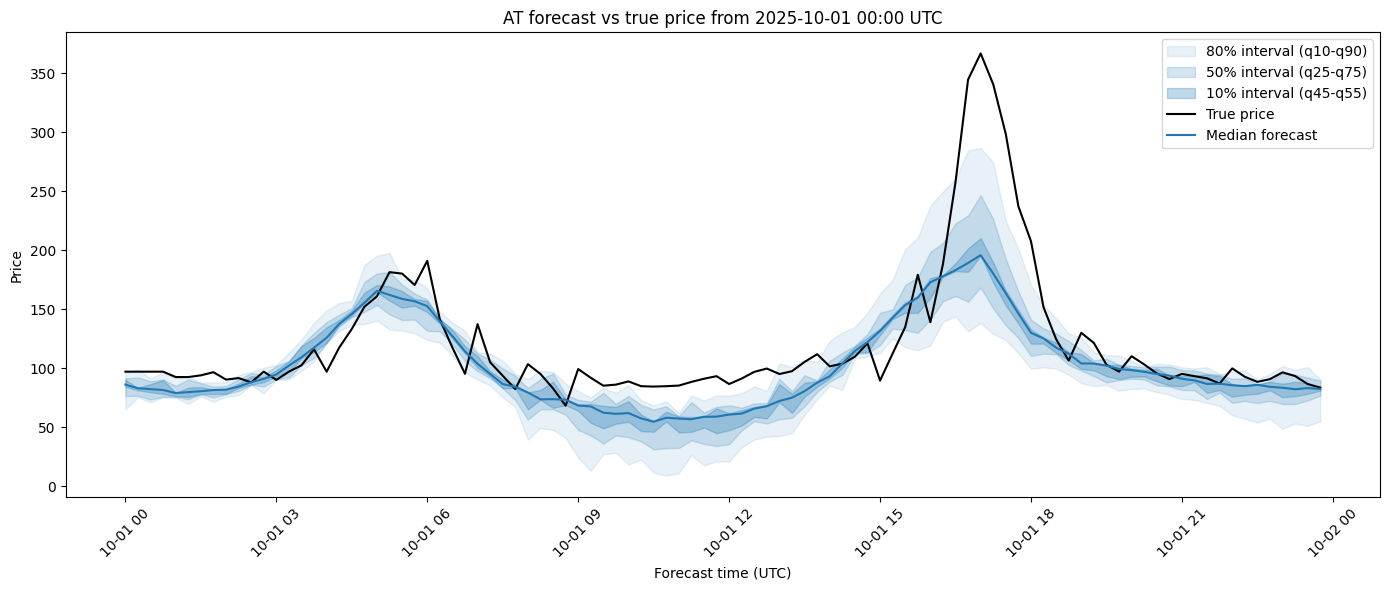

In [26]:
quantiles =  [0.10, 0.25, 0.45, 0.50, 0.55, 0.75, 0.90]

forecast_result = normalize_and_forecast(
    loaded_data=loaded_data,
    phase2_model_path=phase2_model_path,
    forecast_target_country=forecast_target_country,
    forecast_graph_degree=forecast_graph_degree,
    adjacency_dict=adjacency_dict,
    input_countries=countries,
    features=features,
    lag_features=lag_features,
    lead_features=lead_features,
    label_column=label_column,
    x_scalers=x_scalers,
    y_scalers=y_scalers,
    quantiles=quantiles,
)
display(produce_testing_metrics(forecast_result, y_scalers)[['AQL', 'RMSE', 'MAE']])
display(forecast_result["forecast_df"].head())
fig, ax = visualize_forecast(forecast_result)
plt.show()

In [ ]:
#import netron
#netron.start(f"ckpt_place")

Serving 'phase1_best.keras' at http://localhost:8080


('localhost', 8080)